<a href="https://colab.research.google.com/github/NhibltoTec/Classify1/blob/main/chung_k%E1%BA%BFt_EdgeAIArchitecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!gdown "1cmB1rPQ6pOhJs9-VXsISy1bujSX638_Y"

Downloading...
From (original): https://drive.google.com/uc?id=1cmB1rPQ6pOhJs9-VXsISy1bujSX638_Y
From (redirected): https://drive.google.com/uc?id=1cmB1rPQ6pOhJs9-VXsISy1bujSX638_Y&confirm=t&uuid=4c503c19-1cd3-4832-9d7e-9554af1df1d5
To: /content/office_data_for_qualifiers.zip.zip
100% 84.1M/84.1M [00:00<00:00, 97.1MB/s]


In [ ]:
!unzip office_data_for_qualifiers.zip -d data

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: data/train/1/01754.png  
  inflating: data/train/1/01493.png  
  inflating: data/train/1/01482.png  
  inflating: data/train/1/01646.png  
  inflating: data/train/1/01468.png  
  inflating: data/train/1/03151.png  
  inflating: data/train/1/02085.png  
  inflating: data/train/1/02064.png  
  inflating: data/train/1/02483.png  
  inflating: data/train/1/01343.png  
  inflating: data/train/1/03059.png  
  inflating: data/train/1/02226.png  
  inflating: data/train/1/01767.png  
  inflating: data/train/1/03109.png  
  inflating: data/train/1/02632.png  
  inflating: data/train/1/01840.png  
  inflating: data/train/1/01725.png  
  inflating: data/train/1/01726.png  
  inflating: data/train/1/03235.png  
  inflating: data/train/1/03257.png  
  inflating: data/train/1/01838.png  
  inflating: data/train/1/02413.png  
  inflating: data/train/1/01981.png  
  inflating: data/train/1/02956.png  
  inflating: data/train/1/02010

In [ ]:
!pip install onnx2tf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB

In [ ]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm

def analyze_classification_dataset(image_paths, dataset_name):
    brightness_list = []
    blur_list = []
    resolution_list = []
    aspect_ratio_list = []

    print(f"\nĐang phân tích tập {dataset_name} ({len(image_paths)} ảnh)...")

    for path in tqdm(image_paths):
        # Đọc ảnh, giữ nguyên kênh màu
        img = cv2.imread(path)
        if img is None:
            continue

        h, w = img.shape[:2]

        # 1. Tỉ lệ khung hình (Aspect Ratio = W/H)
        # Bằng 1 là hình vuông, < 1 là hình chữ nhật đứng, > 1 là chữ nhật ngang
        aspect_ratio_list.append(w / h)

        # 2. Độ phân giải gốc (Resolution = W * H)
        resolution_list.append(w * h)

        # 3. Độ mờ (Laplacian variance)
        # Càng thấp càng mờ. Càng cao càng sắc nét.
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur = cv2.Laplacian(gray, cv2.CV_64F).var()
        blur_list.append(blur)

        # 4. Độ sáng (Kênh V trong hệ màu HSV)
        # Dao động từ 0 (Đen thui) đến 255 (Trắng sáng)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        brightness = hsv[:, :, 2].mean()
        brightness_list.append(brightness)

    # Đóng gói thống kê
    stats = {
        'aspect_ratio': (np.mean(aspect_ratio_list), np.median(aspect_ratio_list), np.min(aspect_ratio_list), np.max(aspect_ratio_list)),
        'resolution': (np.mean(resolution_list), np.median(resolution_list), np.min(resolution_list), np.max(resolution_list)),
        'brightness': (np.mean(brightness_list), np.median(brightness_list), np.min(brightness_list), np.max(brightness_list)),
        'blur': (np.mean(blur_list), np.median(blur_list), np.min(blur_list), np.max(blur_list))
    }
    return stats

def print_stats(stats, name):
    print(f"--- THỐNG KÊ TẬP {name.upper()} ---")
    print(f"1. Tỉ lệ khung hình (W/H): Mean={stats['aspect_ratio'][0]:.2f}, Median={stats['aspect_ratio'][1]:.2f}, Min={stats['aspect_ratio'][2]:.2f}, Max={stats['aspect_ratio'][3]:.2f}")
    print(f"2. Độ phân giải (Pixels):  Mean={stats['resolution'][0]:.0f}, Median={stats['resolution'][1]:.0f}, Min={stats['resolution'][2]:.0f}, Max={stats['resolution'][3]:.0f}")
    print(f"3. Độ sáng (0-255):        Mean={stats['brightness'][0]:.2f}, Median={stats['brightness'][1]:.2f}, Min={stats['brightness'][2]:.2f}, Max={stats['brightness'][3]:.2f}")
    print(f"4. Độ mờ (Laplacian Var):  Mean={stats['blur'][0]:.2f}, Median={stats['blur'][1]:.2f}, Min={stats['blur'][2]:.2f}, Max={stats['blur'][3]:.2f}")
    print("-" * 50)

# ==========================================
# CÀI ĐẶT ĐƯỜNG DẪN Ở ĐÂY
# Lưu ý: Đổi đuôi .jpg thành .png nếu tập dữ liệu của bạn dùng ảnh PNG
# ==========================================
train_paths = glob('/content/data/train/**/*.png', recursive=True)
test_paths = glob('/content/data/test/*.png', recursive=True)

if len(train_paths) == 0 or len(test_paths) == 0:
    print("LỖI: Không tìm thấy ảnh. Vui lòng kiểm tra lại đường dẫn và định dạng (.jpg, .png, v.v...)")
else:
    train_stats = analyze_classification_dataset(train_paths, "Train")
    test_stats = analyze_classification_dataset(test_paths, "Test")

    print("\n\n" + "="*50)
    print("KẾT QUẢ PHÂN TÍCH (HÃY COPY ĐOẠN DƯỚI ĐÂY GỬI CHO TÔI)")
    print("="*50)
    print_stats(train_stats, "Train")
    print_stats(test_stats, "Test")


Đang phân tích tập Train (9629 ảnh)...


100%|██████████| 9629/9629 [00:06<00:00, 1476.40it/s]



Đang phân tích tập Test (1545 ảnh)...


100%|██████████| 1545/1545 [00:01<00:00, 952.80it/s]



KẾT QUẢ PHÂN TÍCH (HÃY COPY ĐOẠN DƯỚI ĐÂY GỬI CHO TÔI)
--- THỐNG KÊ TẬP TRAIN ---
1. Tỉ lệ khung hình (W/H): Mean=1.01, Median=1.00, Min=0.53, Max=1.42
2. Độ phân giải (Pixels):  Mean=3749, Median=2250, Min=625, Max=49056
3. Độ sáng (0-255):        Mean=113.96, Median=111.25, Min=13.50, Max=251.55
4. Độ mờ (Laplacian Var):  Mean=1838.29, Median=1279.34, Min=12.55, Max=17327.73
--------------------------------------------------
--- THỐNG KÊ TẬP TEST ---
1. Tỉ lệ khung hình (W/H): Mean=1.01, Median=1.01, Min=0.41, Max=1.24
2. Độ phân giải (Pixels):  Mean=3817, Median=2256, Min=675, Max=61712
3. Độ sáng (0-255):        Mean=130.69, Median=130.79, Min=16.97, Max=249.32
4. Độ mờ (Laplacian Var):  Mean=1028.54, Median=579.12, Min=4.72, Max=7559.43
--------------------------------------------------


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder
import torch.optim as op
import os
from PIL import Image
import pandas as pd
import random
import numpy as np


torch.manual_seed(42);
np.random.seed(42);
random.seed(42);
torch.cuda.manual_seed_all(42);
if not os.path.exists('/content/edge-ai-challenge-2026-qualifiers'):
    !unzip -q edge-ai-challenge-2026-qualifiers.zip -d /content/edge-ai-challenge-2026-qualifiers

device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_tf = T.Compose([
    T.Resize((32, 32)),
    T.RandomPerspective(distortion_scale=0.2, p=0.5),
    T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.RandomErasing(p=0.4, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

from torch.utils.data import Subset

full_data = ImageFolder('/content/data/train')

indices = list(range(len(full_data)))
np.random.seed(42)
np.random.shuffle(indices)

split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_set = Subset(
    ImageFolder('/content/data/train', transform=train_tf),
    train_idx
)

val_set = Subset(
    ImageFolder('/content/data/train', transform=test_tf),
    val_idx
)
trainloader = DataLoader(train_set, batch_size=32, shuffle=True)
valloader = DataLoader(val_set, batch_size=32, shuffle=False)

class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.images = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, img_name

testdata = TestDataset('/content/data/test', test_tf)
testloader = DataLoader(testdata, batch_size=32, shuffle=False)


def _dw(in_ch, out_ch, stride=1):
    return nn.Sequential(
        nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
        nn.BatchNorm2d(in_ch),
        nn.ReLU(),

        nn.Conv2d(in_ch, out_ch, 1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(),
    )

#  BUILD MODEL
def build_model(num_classes=10):
    return nn.Sequential(
        # Block 1: 3 -> 32
        nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32 -> 16x16

        # Block 2: 32 -> 64
        nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),

        # Block 3: 64 -> 64 (Lớp mới thêm để tăng chiều sâu)
        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16 -> 8x8

        # Block 4: 64 -> 128
        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8 -> 4x4

        nn.Flatten(),
        nn.Dropout(0.4),
        nn.Linear(128 * 4 * 4, num_classes)
    )
#buil model
model = build_model(num_classes=10)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print("Total params:", total_params)
from torchsummary import summary

summary(model, (3, 32, 32))

lossfunction = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = op.Adam(model.parameters(), lr=1e-3)
# TRAIN
for epoch in range(20):
    model.train()
    train_loss = 0

    for image, label in trainloader:
        image, label = image.to(device), label.to(device)

        optimizer.zero_grad()
        pred = model(image)
        loss = lossfunction(pred, label)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()


    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for image, label in valloader:
            image, label = image.to(device), label.to(device)

            output = model(image)
            pred = torch.argmax(output, dim=1)

            total += label.size(0)
            correct += (pred == label).sum().item()

    acc = correct / total
    print(f"Epoch {epoch} | Loss: {train_loss:.4f} | Val Acc: {acc:.4f}")

unzip:  cannot find or open edge-ai-challenge-2026-qualifiers.zip, edge-ai-challenge-2026-qualifiers.zip.zip or edge-ai-challenge-2026-qualifiers.zip.ZIP.
Total params: 150954
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             864
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
         MaxPool2d-4           [-1, 32, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]          18,432
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,864
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
        MaxPool2d-11             [-1, 64, 8, 8]        

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.datasets import ImageFolder
import torch.optim as op
import os
from PIL import Image
import pandas as pd
import random
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


In [ ]:
import torchvision.transforms as T

train_tf = T.Compose([
    T.Resize((32, 32)),
    T.RandomPerspective(distortion_scale=0.15, p=0.4),
    T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.3, contrast=0.2),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.5, 2.0))], p=0.5),
    T.ToTensor(),
    T.RandomErasing(p=0.4, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

DATA_TRAIN_DIR = '/content/data/train'
DATA_TEST_DIR = '/content/data/test'

full_data = ImageFolder(DATA_TRAIN_DIR)
indices = list(range(len(full_data)))
np.random.seed(42)
np.random.shuffle(indices)

split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_set = Subset(ImageFolder(DATA_TRAIN_DIR, transform=train_tf), train_idx)
val_set = Subset(ImageFolder(DATA_TRAIN_DIR, transform=test_tf), val_idx)

trainloader = DataLoader(train_set, batch_size=32, shuffle=True)
valloader = DataLoader(val_set, batch_size=32, shuffle=False)

# 3. Class Load tập Test
class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.images = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

if os.path.exists(DATA_TEST_DIR):
    testdata = TestDataset(DATA_TEST_DIR, test_tf)
    testloader = DataLoader(testdata, batch_size=32, shuffle=False)

print("Đã chuẩn bị xong DataLoader!")

Đã chuẩn bị xong DataLoader!


In [ ]:
def build_model(num_classes=10):
    return nn.Sequential(
        # Block 1: 3 -> 32
        nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32 -> 16x16

        # Block 2: 32 -> 64
        nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),

        # Block 3: 64 -> 64 (Lớp mới thêm để tăng chiều sâu)
        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16 -> 8x8

        # Block 4: 64 -> 128
        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8 -> 4x4

        nn.Flatten(),
        nn.Dropout(0.4),
        nn.Linear(128 * 4 * 4, num_classes)
    )

# Khởi tạo mô hình
model = build_model(num_classes=10).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Tổng số tham số: {total_params:,}")

# In tóm tắt mô hình
from torchsummary import summary
summary(model, (3, 32, 32))

Tổng số tham số: 150,954
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             864
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
         MaxPool2d-4           [-1, 32, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]          18,432
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,864
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
        MaxPool2d-11             [-1, 64, 8, 8]               0
           Conv2d-12            [-1, 128, 8, 8]          73,728
      BatchNorm2d-13            [-1, 128, 8, 8]             256
             R

In [ ]:
from tqdm import tqdm

EPOCHS = 20

lossfunction = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = op.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

print("Bắt đầu quá trình huấn luyện...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    train_bar = tqdm(trainloader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]", leave=False)

    for image, label in train_bar:
        image, label = image.to(device), label.to(device)

        optimizer.zero_grad()
        pred = model(image)
        loss = lossfunction(pred, label)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        val_bar = tqdm(valloader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val]", leave=False)

        for image, label in val_bar:
            image, label = image.to(device), label.to(device)

            output = model(image)
            pred = torch.argmax(output, dim=1)

            total += label.size(0)
            correct += (pred == label).sum().item()

    acc = correct / total
    avg_loss = train_loss / len(trainloader)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | LR: {current_lr:.6f} | Avg Loss: {avg_loss:.4f} | Val Acc: {acc:.4f}")

torch.save(model.state_dict(), "model_checkpoint.pth")
print("\nĐã lưu trọng số mô hình vào 'model_checkpoint.pth'")

Bắt đầu quá trình huấn luyện...


Epoch 01/20 | LR: 0.001000 | Avg Loss: 1.1248 | Val Acc: 0.9860


Epoch 02/20 | LR: 0.001000 | Avg Loss: 0.7304 | Val Acc: 0.9953


Epoch 03/20 | LR: 0.001000 | Avg Loss: 0.6589 | Val Acc: 0.9990


Epoch 04/20 | LR: 0.001000 | Avg Loss: 0.6218 | Val Acc: 0.9979


...

Epoch 16/20 | LR: 0.000250 | Avg Loss: 0.5399 | Val Acc: 1.0000


Epoch 17/20 | LR: 0.000250 | Avg Loss: 0.5397 | Val Acc: 1.0000


Epoch 18/20 | LR: 0.000250 | Avg Loss: 0.5372 | Val Acc: 1.0000


Epoch 19/20 | LR: 0.000250 | Avg Loss: 0.5364 | Val Acc: 1.0000


Epoch 20/20 | LR: 0.000250 | Avg Loss: 0.5353 | Val Acc: 1.0000

Đã lưu trọng số mô hình vào 'model_checkpoint.pth'


## Float32 16 Convert

In [ ]:
model.eval()

dummy = torch.randn(1, 3, 32, 32).to(device)

torch.onnx.export(
    model,
    dummy,
    "model.onnx",
    opset_version=13
)

# ===== CHECK =====
import onnx
onnx_model = onnx.load("model.onnx")
onnx.checker.check_model(onnx_model)

# ===== CONVERT =====
from onnx2tf import convert

convert(
    input_onnx_file_path="model.onnx",
    output_folder_path="model_tf",
    output_signaturedefs=True,
    disable_group_convolution=True
)

W0513 06:37:02.363000 4301 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0513 06:37:03.310000 4301 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0513 06:37:03.312000 4301 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -

[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 8 of general pattern rewrite rules.

Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Constant   │ 11             │ 11               │
│ Conv       │ 4              │ 4                │
│ Gemm       │ 1              │ 1                │
│ MaxPool    │ 3              │ 3                │
│ Relu       │ 4              │ 4                │
│ Reshape    │ 1              │ 1                │
│ Model Size │ 604.3KiB       │ 590.8KiB         │
└────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ 

flatbuffer_direct lowering:   0%|          | 0/13 [00:00<?, ?it/s]

flatbuffer_direct post-lowering:   0%|          | 0/6 [00:00<?, ?it/s]

flatbuffer_direct export:   0%|          | 0/3 [00:00<?, ?it/s]

flatbuffer_direct write timing: stage=float32 mode=builder_direct total=0.009s serialize=0.009s (sanitize=0.000s build=0.001s pack=0.008s output=0.000s) write=0.001s size=0.58MB
flatbuffer_direct write timing: stage=float16 mode=builder_direct total=0.008s serialize=0.007s (sanitize=0.000s build=0.000s pack=0.007s output=0.000s) write=0.001s size=0.29MB
Float32 tflite output complete! (model_tf/model_float32.tflite)
Float16 tflite output complete! (model_tf/model_float16.tflite)
Tensor correspondence report output complete! (model_tf/model_tensor_correspondence_report.json)


thêm

In [ ]:
import types, sys

# tạo module runtime_version giả
runtime_version = types.ModuleType("runtime_version")

class Domain:
    PUBLIC = 0

def ValidateProtobufRuntimeVersion(*args, **kwargs):
    return True

runtime_version.Domain = Domain
runtime_version.ValidateProtobufRuntimeVersion = ValidateProtobufRuntimeVersion

# gắn vào protobuf
import google.protobuf
google.protobuf.runtime_version = runtime_version
sys.modules["google.protobuf.runtime_version"] = runtime_version

import tensorflow as tf
print("TensorFlow loaded:", tf.__version__)

TensorFlow loaded: 2.20.0


end

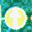

Predict: 6


In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image
from google.colab.patches import cv2_imshow

interpreter = tf.lite.Interpreter(
    model_path="model_tf/model_float32.tflite"
)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

img_pil = Image.open("/content/data/test/00014.png").convert("RGB").resize((32,32))
img = np.array(img_pil)
cv2_imshow(img)

img = img / 255.0
img = (img - 0.5) / 0.5

img = np.expand_dims(img, 0).astype(np.float32)

# inference
interpreter.set_tensor(input_details[0]['index'], img)
interpreter.invoke()

output = interpreter.get_tensor(output_details[0]['index'])
pred = np.argmax(output)

print("Predict:", pred)

In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image
import os
import pandas as pd

# ==========================================
# PHẦN 1: DỰ ĐOÁN VÀ XUẤT FILE CSV
# ==========================================
def generate_predictions(model_path, test_dir, output_csv):
    print("1. Đang chạy mô hình để dự đoán...")

    # Load TFLite model
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    predictions = []

    for img_name in sorted(os.listdir(test_dir)):
        if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
            continue

        img_path = os.path.join(test_dir, img_name)

        # Tiền xử lý ảnh
        img = Image.open(img_path).convert("RGB").resize((32, 32))
        img = np.array(img) / 255.0
        img = (img - 0.5) / 0.5
        img = np.expand_dims(img, 0).astype(np.float32)

        # Inference
        interpreter.set_tensor(input_details[0]['index'], img)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        pred = np.argmax(output)

        # Lấy Id (tên file không đuôi)
        img_id = os.path.splitext(img_name)[0]
        predictions.append({"Id": img_id, "Label": pred})

    # Xuất ra file CSV
    pred_df = pd.DataFrame(predictions)
    pred_df.to_csv(output_csv, index=False)
    print(f"-> Đã xuất thành công file dự đoán: {output_csv}\n")


# ==========================================
# PHẦN 2: ĐỌC LẠI 2 FILE CSV VÀ SO SÁNH
# ==========================================
def evaluate_accuracy(pred_csv, solution_csv):
    print("2. Đang đọc file để so sánh và tính độ chính xác...")

    if not os.path.exists(pred_csv):
        print(f"Lỗi: Không tìm thấy file {pred_csv}")
        return
    if not os.path.exists(solution_csv):
        print(f"Lỗi: Không tìm thấy file {solution_csv}")
        return

    # Đọc lại 2 file CSV từ ổ cứng (Ép kiểu Id về str ngay khi đọc để tránh mất số 0 ở đầu)
    df_pred = pd.read_csv(pred_csv, dtype={'Id': str})
    df_sol = pd.read_csv(solution_csv, dtype={'Id': str})

    # Ghép 2 bảng lại với nhau dựa trên cột Id
    merged_df = pd.merge(df_pred, df_sol, on="Id", suffixes=('_pred', '_true'))

    if len(merged_df) == 0:
        print("Cảnh báo: Không có Id nào khớp nhau giữa 2 file!")
        return

    # --- TÍNH ACCURACY TỔNG ---
    correct = (merged_df['Label_pred'] == merged_df['Label_true']).sum()
    total = len(merged_df)
    acc = correct / total

    print(f"-> Tổng số ảnh được so sánh: {total}")
    print(f"-> Số dự đoán chính xác: {correct}")
    print(f"-> Accuracy Tổng (Overall): {acc * 100:.2f}%\n")

    # --- TÍNH ACCURACY THEO TỪNG TẬP PUBLIC / PRIVATE ---
    # Tìm tên cột usage (phòng trường hợp viết hoa/thường khác nhau)
    usage_col = 'Usage' if 'Usage' in merged_df.columns else ('usage' if 'usage' in merged_df.columns else None)

    if usage_col:
        # Chuẩn hóa chuỗi về chữ thường để so sánh dễ dàng
        merged_df['normalized_usage'] = merged_df[usage_col].astype(str).str.strip().str.lower()

        for usage_type in ['public', 'private']:
            subset = merged_df[merged_df['normalized_usage'] == usage_type]
            if len(subset) > 0:
                sub_correct = (subset['Label_pred'] == subset['Label_true']).sum()
                sub_total = len(subset)
                sub_acc = sub_correct / sub_total
                print(f"   [+] Accuracy {usage_type.capitalize():<7} ({sub_total:^5} ảnh): {sub_acc * 100:.2f}%")
        print("\n")
    else:
        print("Cảnh báo: Không tìm thấy cột 'Usage' hoặc 'usage' trong file solution để chia Public/Private.\n")


# ==========================================
# CHẠY CHÍNH THỨC (MAIN LOOP)
# ==========================================
if __name__ == "__main__":
    # Khai báo các đường dẫn
    MODEL_PATH = "model_tf/model_float32.tflite"
    TEST_DIR = "/content/data/test"
    PRED_CSV_PATH = "submission.csv"
    SOLUTION_CSV_PATH = "/content/solution.csv" # Sửa lại nếu file solution của bạn để ở thư mục khác

    # Bước 1: Gọi hàm chạy Model và xuất file submission.csv
    generate_predictions(MODEL_PATH, TEST_DIR, PRED_CSV_PATH)

    # Bước 2: Gọi hàm đọc lại file submission.csv và solution.csv để chấm điểm
    evaluate_accuracy(PRED_CSV_PATH, SOLUTION_CSV_PATH)

1. Đang chạy mô hình để dự đoán...
-> Đã xuất thành công file dự đoán: submission.csv

2. Đang đọc file để so sánh và tính độ chính xác...
-> Tổng số ảnh được so sánh: 1545
-> Số dự đoán chính xác: 1437
-> Accuracy Tổng (Overall): 93.01%

   [+] Accuracy Public  ( 463  ảnh): 92.01%
   [+] Accuracy Private (1082  ảnh): 93.44%




# Teacher model

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

def build_teacher_model(num_classes=10, model_name='resnet34'):
    """
    Xây dựng mô hình Teacher (ResNet34 hoặc ResNet50)
    được tối ưu hóa cho ảnh kích thước nhỏ 32x32.
    """

    # 1. Tải mô hình đã pre-trained (Học từ ImageNet sẽ giúp mô hình hội tụ cực nhanh)
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    else: # Mặc định dùng resnet34 là đủ đẹp để làm Teacher
        model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

    # ==========================================
    # 2. CHỈNH SỬA CRITICAL CHO ẢNH 32x32
    # ==========================================
    # Mặc định của ResNet là Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
    # Lớp này thu nhỏ ảnh 32x32 xuống 16x16 ngay lập tức (mất quá nhiều thông tin)
    # Ta thay bằng kernel_size=3, stride=1 để giữ nguyên độ phân giải 32x32 ở bước đầu
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # Mặc định ResNet có MaxPool sau conv1 thu nhỏ ảnh tiếp từ 16x16 xuống 8x8.
    # Ta tắt nó đi bằng nn.Identity() để bảo toàn kích thước feature map
    model.maxpool = nn.Identity()

    # ==========================================
    # 3. CHỈNH SỬA LỚP PHÂN LOẠI CUỐI (CLASSIFIER)
    # ==========================================
    in_features = model.fc.in_features

    # Thêm Dropout để chống Overfitting (vì model khá to so với dataset của bạn)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )

    return model

# Khởi tạo thử mô hình
teacher_model = build_teacher_model(num_classes=10, model_name='resnet34')

# Test với input giả lập 32x32
dummy_input = torch.randn(1, 3, 32, 32)
output = teacher_model(dummy_input)
print(f"Output shape: {output.shape}")
# Kì vọng: torch.Size([1, 10])

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 202MB/s]


Output shape: torch.Size([1, 10])


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torch.optim as op
import os
from PIL import Image
import random
import numpy as np
from torchsummary import summary

# 1. THIẾT LẬP SEED VÀ THIẾT BỊ
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)

if not os.path.exists('/content/edge-ai-challenge-2026-qualifiers'):
    !unzip -q edge-ai-challenge-2026-qualifiers.zip -d /content/edge-ai-challenge-2026-qualifiers

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 2. PIPELINE AUGMENTATION (Đã tối ưu dựa trên EDA report)
train_tf = T.Compose([
    T.Resize((32, 32)),
    T.RandomPerspective(distortion_scale=0.15, p=0.4),
    T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    # Tăng brightness để khớp với tập test sáng hơn
    T.ColorJitter(brightness=0.3, contrast=0.2),
    # Thêm Gaussian Blur để khớp với tập test bị mờ
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.5, 2.0))], p=0.5),
    T.ToTensor(),
    T.RandomErasing(p=0.4, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

# 3. CHUẨN BỊ DỮ LIỆU
full_data = ImageFolder('/content/data/train')

indices = list(range(len(full_data)))
np.random.shuffle(indices)

split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_set = Subset(
    ImageFolder('/content/data/train', transform=train_tf),
    train_idx
)

val_set = Subset(
    ImageFolder('/content/data/train', transform=test_tf),
    val_idx
)

trainloader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
valloader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.images = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

testdata = TestDataset('/content/data/test', test_tf)
testloader = DataLoader(testdata, batch_size=32, shuffle=False)

# 4. XÂY DỰNG TEACHER MODEL (ResNet-34 tùy chỉnh cho 32x32)
def build_teacher_model(num_classes=10):
    # Sử dụng ResNet-34 với pre-trained weights để hội tụ nhanh
    model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

    # Sửa lớp Conv1 để không làm giảm kích thước ảnh (32x32 -> 32x32 thay vì 16x16)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # Loại bỏ MaxPool để giữ nguyên spatial dimensions
    model.maxpool = nn.Identity()

    # Thêm Dropout và chỉnh số ngõ ra của lớp phân loại
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_teacher_model(num_classes=10)
model.to(device)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
summary(model, (3, 32, 32))

# 5. THIẾT LẬP TRAINING
lossfunction = nn.CrossEntropyLoss(label_smoothing=0.1)
# Giảm LR xuống 3e-4 (chuẩn cho fine-tuning ResNet) thay vì 1e-3
optimizer = op.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
# Scheduler giảm LR khi Val Acc ngừng tăng
scheduler = op.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# 6. VÒNG LẶP HUẤN LUYỆN
best_val_acc = 0.0
epochs = 30 # Tăng số epoch lên vì có scheduler hỗ trợ

for epoch in range(epochs):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0

    for image, label in trainloader:
        image, label = image.to(device), label.to(device)

        optimizer.zero_grad()
        pred = model(image)
        loss = lossfunction(pred, label)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(trainloader)

    # --- VALIDATION ---
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for image, label in valloader:
            image, label = image.to(device), label.to(device)

            output = model(image)
            pred = torch.argmax(output, dim=1)

            total += label.size(0)
            correct += (pred == label).sum().item()

    val_acc = correct / total

    # Cập nhật Learning Rate
    scheduler.step(val_acc)

    # Lưu mô hình tốt nhất để dùng cho Knowledge Distillation sau này
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_teacher_weights.pth')
        saved_msg = "--> Saved Best Model!"
    else:
        saved_msg = ""

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{epochs} | LR: {current_lr:.6f} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f} {saved_msg}")

print(f"\nHuấn luyện hoàn tất. Val Acc cao nhất: {best_val_acc:.4f}")
print("Trọng số của Teacher đã được lưu tại: 'best_teacher_weights.pth'")

unzip:  cannot find or open edge-ai-challenge-2026-qualifiers.zip, edge-ai-challenge-2026-qualifiers.zip.zip or edge-ai-challenge-2026-qualifiers.zip.ZIP.
Using device: cuda
Total parameters: 21,282,122
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
          Identity-4           [-1, 64, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]          36,864
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
             ReLU-10           [-1, 64, 32, 32]               0
       BasicBlock-11        

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'

test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.images = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

def build_teacher_model(num_classes=10):
    model = models.resnet34(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

def build_teacher_densenet(num_classes=10):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

    # Sửa Conv0 để giữ nguyên kích thước 32x32
    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # Bỏ Pool0 để tránh bóp ảnh quá nhỏ ngay từ đầu
    model.features.pool0 = nn.Identity()

    # Tùy chỉnh lớp phân loại
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

def generate_predictions(model_path, test_dir, output_csv):
    print("1. Đang khởi tạo mô hình và tải trọng số...")
    model = build_teacher_model(num_classes=10)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    print("2. Đang chuẩn bị DataLoader cho tập Test...")
    testdata = TestDataset(test_dir, test_tf)
    testloader = DataLoader(testdata, batch_size=128, shuffle=False, num_workers=2)

    predictions = []

    print("3. Bắt đầu chạy dự đoán (Inference)...")
    with torch.no_grad():
        for images, img_names in testloader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            for img_name, pred in zip(img_names, preds):
                img_id = os.path.splitext(img_name)[0]
                predictions.append({"Id": img_id, "Label": pred})
    pred_df = pd.DataFrame(predictions)
    pred_df.to_csv(output_csv, index=False)
    print(f"-> Đã xuất thành công file dự đoán: {output_csv}\n")

def evaluate_accuracy(pred_csv, solution_csv):
    print("4. Đang đọc file để so sánh và tính độ chính xác...")

    if not os.path.exists(pred_csv):
        print(f"Lỗi: Không tìm thấy file {pred_csv}")
        return
    if not os.path.exists(solution_csv):
        print(f"Bỏ qua bước so sánh vì không tìm thấy file Solution: {solution_csv}")
        return

    df_pred = pd.read_csv(pred_csv)
    df_sol = pd.read_csv(solution_csv)

    df_pred['Id'] = df_pred['Id'].astype(str)
    df_sol['Id'] = df_sol['Id'].astype(str)

    merged_df = pd.merge(df_pred, df_sol, on="Id", suffixes=('_pred', '_true'))

    if len(merged_df) == 0:
        print("Cảnh báo: Không có Id nào khớp nhau giữa 2 file!")
        return

    correct = (merged_df['Label_pred'] == merged_df['Label_true']).sum()
    total = len(merged_df)
    acc = correct / total

    print(f"-> Tổng số ảnh được so sánh: {total}")
    print(f"-> Số dự đoán chính xác: {correct}")
    print(f"-> Accuracy (Độ chính xác thực tế): {acc * 100:.2f}%")


if __name__ == "__main__":
    MODEL_PATH = "best_teacher_weights.pth"
    TEST_DIR = "/content/data/test"
    PRED_CSV_PATH = "submission.csv"
    SOLUTION_CSV_PATH = "/content/solution.csv"

    generate_predictions(MODEL_PATH, TEST_DIR, PRED_CSV_PATH)
    evaluate_accuracy(PRED_CSV_PATH, SOLUTION_CSV_PATH)

1. Đang khởi tạo mô hình và tải trọng số...
2. Đang chuẩn bị DataLoader cho tập Test...
3. Bắt đầu chạy dự đoán (Inference)...
-> Đã xuất thành công file dự đoán: submission.csv

4. Đang đọc file để so sánh và tính độ chính xác...
-> Tổng số ảnh được so sánh: 1545
-> Số dự đoán chính xác: 1439
-> Accuracy (Độ chính xác thực tế): 93.14%


Đang chạy Inference trên 1545 mẫu...


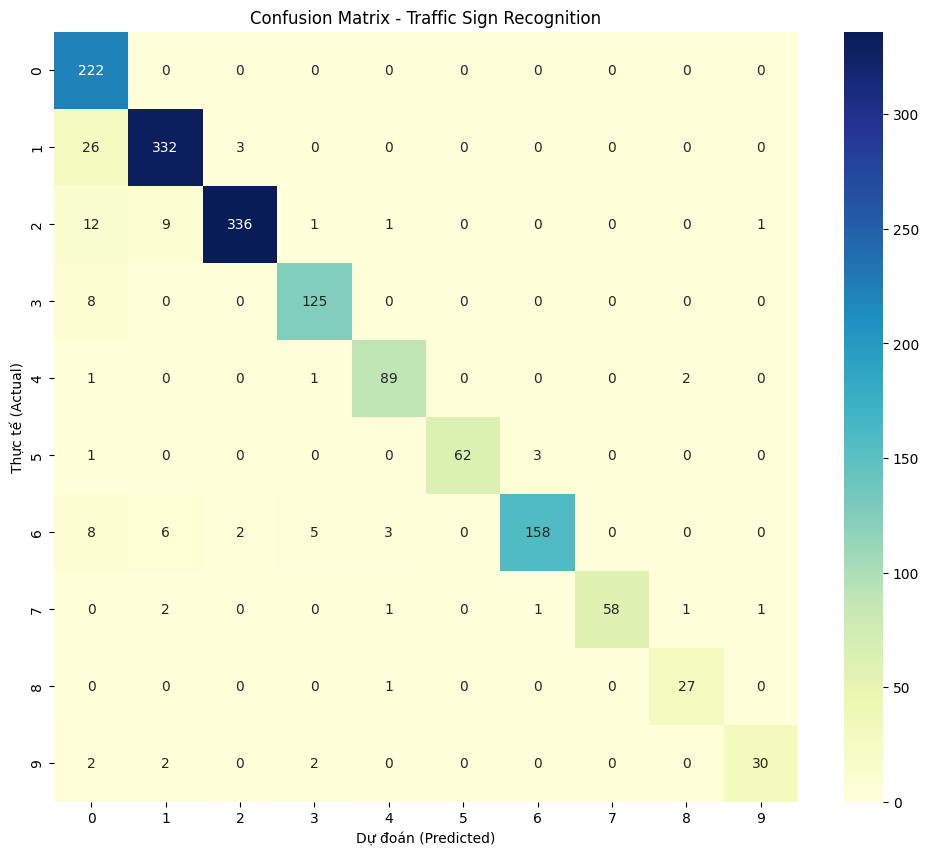


--- TOP CLASS YẾU NHẤT (F1-SCORE THẤP) ---
 Class  F1-Score  Train_Size  Errors
     9  0.882353         360       6
     0  0.884462        1320       0
     6  0.918605        1200      24
     8  0.931034         210       1
     1  0.932584        2100      29
     3  0.936330         780       8
     4  0.946809         689       4
     7  0.950820         390       6
     2  0.958631        2160      24
     5  0.968750         420       4

--- CÁC CẶP NHẦM LẪN NHIỀU NHẤT ---
Thực tế class 1 bị nhìn nhầm thành class 0: 26 lần
Thực tế class 2 bị nhìn nhầm thành class 0: 12 lần
Thực tế class 2 bị nhìn nhầm thành class 1: 9 lần
Thực tế class 3 bị nhìn nhầm thành class 0: 8 lần
Thực tế class 6 bị nhìn nhầm thành class 0: 8 lần


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Config lại cho khớp model đã train
test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

def build_teacher_model(num_classes=10):
    model = models.resnet34(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.fc.in_features, num_classes))
    return model

def analyze_errors_expert(model_path, train_dir, test_dir, solution_csv):
    # 1. Đọc số lượng ảnh mỗi class trong tập Train
    train_counts = {int(c): len(os.listdir(os.path.join(train_dir, c)))
                    for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))}
    num_classes = len(train_counts)

    # 2. Load Model
    model = build_teacher_model(num_classes=num_classes)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # 3. Load Solution (Ép kiểu Id về string để giữ 0000x)
    df_sol = pd.read_csv(solution_csv, dtype={'Id': str})

    # Quét thư mục test một lần để mapping
    all_test_files = {os.path.splitext(f)[0]: f for f in os.listdir(test_dir)}

    y_true, y_pred, ids = [], [], []

    print(f"Đang chạy Inference trên {len(df_sol)} mẫu...")
    with torch.no_grad():
        for _, row in df_sol.iterrows():
            # Chuẩn hóa ID về 5 chữ số (zfill)
            clean_id = str(row['Id']).split('.')[0].zfill(5)
            label_true = int(row['Label'])

            if clean_id in all_test_files:
                img_path = os.path.join(test_dir, all_test_files[clean_id])
                img = Image.open(img_path).convert('RGB')
                img = test_tf(img).unsqueeze(0).to(device)

                output = model(img)
                pred = torch.argmax(output, dim=1).item()

                y_true.append(label_true)
                y_pred.append(pred)
                ids.append(clean_id)

    # 4. Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title('Confusion Matrix - Traffic Sign Recognition')
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.show()

    # 5. Báo cáo phân tích sâu
    report = classification_report(y_true, y_pred, output_dict=True)
    stats = []
    for cls_id in range(num_classes):
        cls_key = str(cls_id)
        if cls_key in report:
            stats.append({
                'Class': cls_id,
                'F1-Score': report[cls_key]['f1-score'],
                'Train_Size': train_counts.get(cls_id, 0),
                'Errors': (np.array(y_true) == cls_id).sum() - cm[cls_id, cls_id]
            })

    df_stats = pd.DataFrame(stats).sort_values(by='F1-Score')
    print("\n--- TOP CLASS YẾU NHẤT (F1-SCORE THẤP) ---")
    print(df_stats.head(10).to_string(index=False))

    # Tìm ra các cặp class hay bị lẫn lộn nhất
    print("\n--- CÁC CẶP NHẦM LẪN NHIỀU NHẤT ---")
    flat_cm = []
    for i in range(len(cm)):
        for j in range(len(cm)):
            if i != j and cm[i, j] > 0:
                flat_cm.append((i, j, cm[i, j]))
    flat_cm.sort(key=lambda x: x[2], reverse=True)
    for i, j, count in flat_cm[:5]:
        print(f"Thực tế class {i} bị nhìn nhầm thành class {j}: {count} lần")

if __name__ == "__main__":
    analyze_errors_expert(
        "best_teacher_weights.pth",
        "/content/data/train",
        "/content/data/test",
        "/content/solution.csv"
    )

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision.datasets import ImageFolder
import torch.optim as op
import os
from PIL import Image
import random
import numpy as np
from torchsummary import summary
from sklearn.model_selection import train_test_split

# 1. THIẾT LẬP SEED VÀ THIẾT BỊ
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)

# Khởi tạo thư mục và giải nén (nếu cần)
if not os.path.exists('/content/edge-ai-challenge-2026-qualifiers'):
    !unzip -q edge-ai-challenge-2026-qualifiers.zip -d /content/edge-ai-challenge-2026-qualifiers

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 2. PIPELINE AUGMENTATION (Tối ưu theo EDA)
train_tf = T.Compose([
    T.Resize((32, 32)),
    # Giảm mức độ méo hình vì ảnh 32x32 rất dễ mất chi tiết
    T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),

    # Test set sáng hơn Train set -> Tăng cường độ sáng
    T.ColorJitter(brightness=0.2, contrast=0.2),

    # Test set mờ hơn rất nhiều (Laplacian Var thấp hơn) -> Áp dụng Blur
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.5, 1.5))], p=0.4),

    T.ToTensor(),
    # Giảm mức độ che khuất (Erasing) vì ảnh nhỏ
    T.RandomErasing(p=0.2, scale=(0.02, 0.08), ratio=(0.3, 3.3), value=0),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

# 3. CHUẨN BỊ DỮ LIỆU & XỬ LÝ MẤT CÂN BẰNG
# Tách riêng 2 ImageFolder để không bị lẫn lộn Transform giữa Train và Val
train_dataset_full = ImageFolder('/content/data/train', transform=train_tf)
val_dataset_full = ImageFolder('/content/data/train', transform=test_tf)

targets = train_dataset_full.targets

# Stratified Split: Đảm bảo Val set có đủ mặt các class khó (như class 9)
train_idx, val_idx = train_test_split(
    list(range(len(targets))),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_set = Subset(train_dataset_full, train_idx)
val_set = Subset(val_dataset_full, val_idx)

# TÍNH TOÁN WEIGHTS CHO SAMPLER ĐỂ CÂN BẰNG DỮ LIỆU
train_targets = [targets[i] for i in train_idx]
class_counts = np.bincount(train_targets)
# Trọng số tỉ lệ nghịch với số lượng mẫu của class đó
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_targets]

# Sampler sẽ tự động chọn nhiều ảnh từ class 9, 7 và ít ảnh từ class 1, 2
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Chú ý: Khi dùng sampler thì không dùng shuffle=True nữa
trainloader = DataLoader(train_set, batch_size=32, sampler=sampler, num_workers=2)
valloader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.images = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

testdata = TestDataset('/content/data/test', test_tf)
testloader = DataLoader(testdata, batch_size=32, shuffle=False)

# 4. XÂY DỰNG TEACHER MODEL
def build_teacher_model(num_classes=10):
    model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
    # Sửa lớp Conv1 để không làm giảm kích thước ảnh 32x32 quá nhanh
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5), # Regularization chống overfitting
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_teacher_model(num_classes=10)
model.to(device)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# 5. THIẾT LẬP TRAINING
lossfunction = nn.CrossEntropyLoss(label_smoothing=0.1)
# Đổi sang AdamW để có Weight Decay hoạt động hiệu quả hơn Adam thường
optimizer = op.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

# Dùng CosineAnnealingLR giúp mượt mà hơn khi fine-tuning ở các epoch cuối
epochs = 35
scheduler = op.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

# 6. VÒNG LẶP HUẤN LUYỆN THÔNG MINH (LƯU THEO ACC VÀ LOSS)
best_val_acc = 0.0
best_val_loss = float('inf')

for epoch in range(epochs):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0

    for image, label in trainloader:
        image, label = image.to(device), label.to(device)

        optimizer.zero_grad()
        pred = model(image)
        loss = lossfunction(pred, label)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(trainloader)

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for image, label in valloader:
            image, label = image.to(device), label.to(device)

            output = model(image)
            loss = lossfunction(output, label)
            val_loss += loss.item()

            pred = torch.argmax(output, dim=1)
            total += label.size(0)
            correct += (pred == label).sum().item()

    avg_val_loss = val_loss / len(valloader)
    val_acc = correct / total

    # Cập nhật Learning Rate
    scheduler.step()

    # --- LOGIC LƯU MODEL MỚI ---
    saved_msg = ""
    # Ưu tiên 1: Cải thiện Accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = avg_val_loss # Cập nhật lại loss tốt nhất tương ứng với Acc này
        torch.save(model.state_dict(), 'best_teacher_weights_with_transform.pth')
        saved_msg = "--> Saved Best Model (Acc Improved)!"

    # Ưu tiên 2: Accuracy giữ nguyên nhưng Model tự tin hơn (Loss giảm)
    elif val_acc == best_val_acc and avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_teacher_weights.pth')
        saved_msg = "--> Saved Best Model (Loss Improved)!"

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{epochs} | LR: {current_lr:.6f} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} {saved_msg}")

print(f"\nHuấn luyện hoàn tất. Val Acc cao nhất: {best_val_acc:.4f} (với Val Loss: {best_val_loss:.4f})")
print("Trọng số của Teacher đã được lưu tại: 'best_teacher_weights.pth'")

unzip:  cannot find or open edge-ai-challenge-2026-qualifiers.zip, edge-ai-challenge-2026-qualifiers.zip.zip or edge-ai-challenge-2026-qualifiers.zip.ZIP.
Using device: cuda
Total parameters: 21,282,122
Epoch 01/35 | LR: 0.000299 | Train Loss: 0.7790 | Val Loss: 0.5172 | Val Acc: 1.0000 --> Saved Best Model (Acc Improved)!
Epoch 02/35 | LR: 0.000298 | Train Loss: 0.5647 | Val Loss: 0.5147 | Val Acc: 1.0000 --> Saved Best Model (Loss Improved)!
Epoch 03/35 | LR: 0.000295 | Train Loss: 0.5445 | Val Loss: 0.5098 | Val Acc: 0.9995 
Epoch 04/35 | LR: 0.000290 | Train Loss: 0.5416 | Val Loss: 0.5079 | Val Acc: 1.0000 --> Saved Best Model (Loss Improved)!
Epoch 05/35 | LR: 0.000285 | Train Loss: 0.5357 | Val Loss: 0.5046 | Val Acc: 0.9995 
Epoch 06/35 | LR: 0.000279 | Train Loss: 0.5240 | Val Loss: 0.5033 | Val Acc: 1.0000 --> Saved Best Model (Loss Improved)!
Epoch 07/35 | LR: 0.000271 | Train Loss: 0.5208 | Val Loss: 0.5024 | Val Acc: 1.0000 --> Saved Best Model (Loss Improved)!
Epoch 08/35

Đang chạy Inference trên 1545 mẫu...


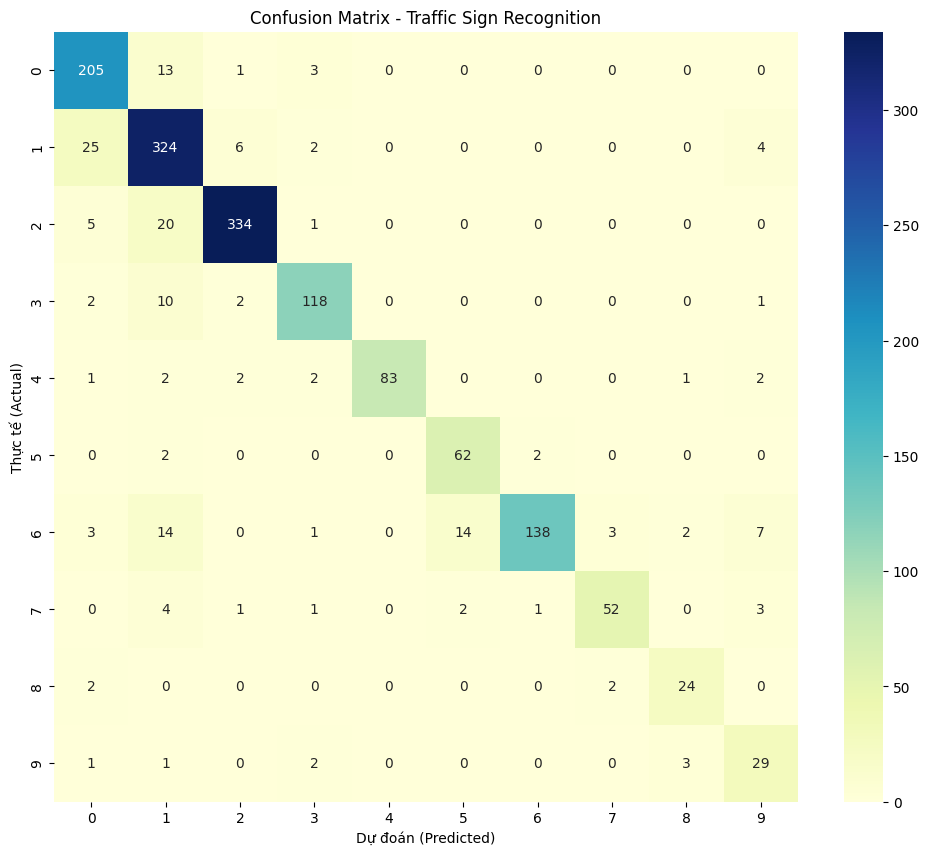


--- TOP CLASS YẾU NHẤT (F1-SCORE THẤP) ---
 Class  F1-Score  Train_Size  Errors
     9  0.707317         360       7
     8  0.827586         210       4
     6  0.854489        1200      44
     7  0.859504         390      12
     5  0.861111         420       4
     1  0.862850        2100      37
     0  0.879828        1320      17
     3  0.897338         780      15
     4  0.943182         689      10
     2  0.946176        2160      26

--- CÁC CẶP NHẦM LẪN NHIỀU NHẤT ---
Thực tế class 1 bị nhìn nhầm thành class 0: 25 lần
Thực tế class 2 bị nhìn nhầm thành class 1: 20 lần
Thực tế class 6 bị nhìn nhầm thành class 1: 14 lần
Thực tế class 6 bị nhìn nhầm thành class 5: 14 lần
Thực tế class 0 bị nhìn nhầm thành class 1: 13 lần


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Config lại cho khớp model đã train
test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

def build_teacher_model(num_classes=10):
    model = models.resnet34(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.fc.in_features, num_classes))
    return model

def analyze_errors_expert(model_path, train_dir, test_dir, solution_csv):
    # 1. Đọc số lượng ảnh mỗi class trong tập Train
    train_counts = {int(c): len(os.listdir(os.path.join(train_dir, c)))
                    for c in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, c))}
    num_classes = len(train_counts)

    # 2. Load Model
    model = build_teacher_model(num_classes=num_classes)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # 3. Load Solution (Ép kiểu Id về string để giữ 0000x)
    df_sol = pd.read_csv(solution_csv, dtype={'Id': str})

    # Quét thư mục test một lần để mapping
    all_test_files = {os.path.splitext(f)[0]: f for f in os.listdir(test_dir)}

    y_true, y_pred, ids = [], [], []

    print(f"Đang chạy Inference trên {len(df_sol)} mẫu...")
    with torch.no_grad():
        for _, row in df_sol.iterrows():
            # Chuẩn hóa ID về 5 chữ số (zfill)
            clean_id = str(row['Id']).split('.')[0].zfill(5)
            label_true = int(row['Label'])

            if clean_id in all_test_files:
                img_path = os.path.join(test_dir, all_test_files[clean_id])
                img = Image.open(img_path).convert('RGB')
                img = test_tf(img).unsqueeze(0).to(device)

                output = model(img)
                pred = torch.argmax(output, dim=1).item()

                y_true.append(label_true)
                y_pred.append(pred)
                ids.append(clean_id)

    # 4. Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title('Confusion Matrix - Traffic Sign Recognition')
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.show()

    # 5. Báo cáo phân tích sâu
    report = classification_report(y_true, y_pred, output_dict=True)
    stats = []
    for cls_id in range(num_classes):
        cls_key = str(cls_id)
        if cls_key in report:
            stats.append({
                'Class': cls_id,
                'F1-Score': report[cls_key]['f1-score'],
                'Train_Size': train_counts.get(cls_id, 0),
                'Errors': (np.array(y_true) == cls_id).sum() - cm[cls_id, cls_id]
            })

    df_stats = pd.DataFrame(stats).sort_values(by='F1-Score')
    print("\n--- TOP CLASS YẾU NHẤT (F1-SCORE THẤP) ---")
    print(df_stats.head(10).to_string(index=False))

    # Tìm ra các cặp class hay bị lẫn lộn nhất
    print("\n--- CÁC CẶP NHẦM LẪN NHIỀU NHẤT ---")
    flat_cm = []
    for i in range(len(cm)):
        for j in range(len(cm)):
            if i != j and cm[i, j] > 0:
                flat_cm.append((i, j, cm[i, j]))
    flat_cm.sort(key=lambda x: x[2], reverse=True)
    for i, j, count in flat_cm[:5]:
        print(f"Thực tế class {i} bị nhìn nhầm thành class {j}: {count} lần")

if __name__ == "__main__":
    analyze_errors_expert(
        "best_teacher_weights_with_transform.pth",
        "/content/data/train",
        "/content/data/test",
        "/content/solution.csv"
    )

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'

test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.images = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

def build_teacher_model(num_classes=10):
    model = models.resnet34(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

def generate_predictions(model_path, test_dir, output_csv):
    print("1. Đang khởi tạo mô hình và tải trọng số...")
    model = build_teacher_model(num_classes=10)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    print("2. Đang chuẩn bị DataLoader cho tập Test...")
    testdata = TestDataset(test_dir, test_tf)
    testloader = DataLoader(testdata, batch_size=128, shuffle=False, num_workers=2)

    predictions = []

    print("3. Bắt đầu chạy dự đoán (Inference)...")
    with torch.no_grad():
        for images, img_names in testloader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            for img_name, pred in zip(img_names, preds):
                img_id = os.path.splitext(img_name)[0]
                predictions.append({"Id": img_id, "Label": pred})
    pred_df = pd.DataFrame(predictions)
    pred_df.to_csv(output_csv, index=False)
    print(f"-> Đã xuất thành công file dự đoán: {output_csv}\n")

def evaluate_accuracy(pred_csv, solution_csv):
    print("4. Đang đọc file để so sánh và tính độ chính xác...")

    if not os.path.exists(pred_csv):
        print(f"Lỗi: Không tìm thấy file {pred_csv}")
        return
    if not os.path.exists(solution_csv):
        print(f"Bỏ qua bước so sánh vì không tìm thấy file Solution: {solution_csv}")
        return

    df_pred = pd.read_csv(pred_csv)
    df_sol = pd.read_csv(solution_csv)

    df_pred['Id'] = df_pred['Id'].astype(str)
    df_sol['Id'] = df_sol['Id'].astype(str)

    merged_df = pd.merge(df_pred, df_sol, on="Id", suffixes=('_pred', '_true'))

    if len(merged_df) == 0:
        print("Cảnh báo: Không có Id nào khớp nhau giữa 2 file!")
        return

    correct = (merged_df['Label_pred'] == merged_df['Label_true']).sum()
    total = len(merged_df)
    acc = correct / total

    print(f"-> Tổng số ảnh được so sánh: {total}")
    print(f"-> Số dự đoán chính xác: {correct}")
    print(f"-> Accuracy (Độ chính xác thực tế): {acc * 100:.2f}%")


if __name__ == "__main__":
    MODEL_PATH = "best_teacher_weights.pth"
    TEST_DIR = "/content/data/test"
    PRED_CSV_PATH = "submission.csv"
    SOLUTION_CSV_PATH = "/content/solution.csv"

    generate_predictions(MODEL_PATH, TEST_DIR, PRED_CSV_PATH)
    evaluate_accuracy(PRED_CSV_PATH, SOLUTION_CSV_PATH)

1. Đang khởi tạo mô hình và tải trọng số...
2. Đang chuẩn bị DataLoader cho tập Test...
3. Bắt đầu chạy dự đoán (Inference)...
-> Đã xuất thành công file dự đoán: submission.csv

4. Đang đọc file để so sánh và tính độ chính xác...
-> Tổng số ảnh được so sánh: 1545
-> Số dự đoán chính xác: 1466
-> Accuracy (Độ chính xác thực tế): 94.89%


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torch.optim as op
import os
import pandas as pd
from PIL import Image
import random
import numpy as np
from tqdm.auto import tqdm # Đã thêm tqdm

# 1. THIẾT LẬP SEED VÀ THIẾT BỊ
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)

if not os.path.exists('/content/edge-ai-challenge-2026-qualifiers'):
    !unzip -q edge-ai-challenge-2026-qualifiers.zip -d /content/edge-ai-challenge-2026-qualifiers

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 2. PIPELINE AUGMENTATION
train_tf = T.Compose([
    T.Resize((32, 32)),
    T.RandomPerspective(distortion_scale=0.15, p=0.4),
    T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.3, contrast=0.2),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.5, 2.0))], p=0.5),
    T.ToTensor(),
    T.RandomErasing(p=0.4, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

# 3. CHUẨN BỊ DỮ LIỆU
full_data = ImageFolder('/content/data/train')

indices = list(range(len(full_data)))
np.random.shuffle(indices)

split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_set = Subset(ImageFolder('/content/data/train', transform=train_tf), train_idx)
val_set = Subset(ImageFolder('/content/data/train', transform=test_tf), val_idx)

trainloader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=0)
valloader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=0)

# --- ĐỌC SOLUTION VÀ CẬP NHẬT TEST DATASET ---
df_sol = pd.read_csv('/content/solution.csv', dtype={'Id': str})
sol_dict = {str(row['Id']).split('.')[0].zfill(5): int(row['Label']) for _, row in df_sol.iterrows()}

class TestDatasetWithLabels(torch.utils.data.Dataset):
    def __init__(self, img_dir, transform=None, sol_dict=None):
        self.img_dir = img_dir
        self.images = sorted(os.listdir(img_dir))
        self.transform = transform
        self.sol_dict = sol_dict

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        clean_id = img_name.split('.')[0].zfill(5)
        label = self.sol_dict.get(clean_id, -1)

        return image, label

testdata = TestDatasetWithLabels('/content/data/test', test_tf, sol_dict)
testloader = DataLoader(testdata, batch_size=32, shuffle=False, num_workers=0)

# 4. XÂY DỰNG TEACHER MODEL
def build_teacher_densenet(num_classes=10):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.features.pool0 = nn.Identity()
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

def build_teacher_densenet201(num_classes=10):
    # Load phiên bản mạnh nhất: DenseNet-201
    model = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)

    # Vẫn giữ nguyên bài toán: Cứu lấy ảnh 32x32
    # 1. Sửa Conv0
    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # 2. Bỏ Pool0
    model.features.pool0 = nn.Identity()

    # 3. Tùy chỉnh lớp phân loại cuối với Dropout để chống Overfitting
    in_features = model.classifier.in_features # Ở bản 201, số này sẽ lớn hơn bản 121
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

def build_teacher_resnet50(num_classes=10):
    model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.DEFAULT)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_teacher_densenet(num_classes=10)
model.to(device)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# 5. THIẾT LẬP TRAINING
lossfunction = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = op.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = op.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_test_acc = 0.0
best_val_loss = float('inf')
epochs = 30

# 6. VÒNG LẶP HUẤN LUYỆN
for epoch in range(epochs):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0

    # Bọc trainloader bằng tqdm
    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+1:02d}/{epochs} [Train]", leave=False)

    for image, label in train_pbar:
        image, label = image.to(device), label.to(device)
        optimizer.zero_grad()
        pred = model(image)
        loss = lossfunction(pred, label)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        # Cập nhật giá trị Loss lên thanh tiến trình
        train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(trainloader)

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # Bọc valloader bằng tqdm
    val_pbar = tqdm(valloader, desc=f"Epoch {epoch+1:02d}/{epochs} [Val]", leave=False)

    with torch.no_grad():
        for image, label in val_pbar:
            image, label = image.to(device), label.to(device)
            output = model(image)
            loss = lossfunction(output, label)
            val_loss += loss.item()

            pred = torch.argmax(output, dim=1)
            val_total += label.size(0)
            val_correct += (pred == label).sum().item()

    avg_val_loss = val_loss / len(valloader)
    val_acc = val_correct / val_total

    # --- TEST EVALUATION ---
    test_correct = 0
    test_total = 0

    # Bọc testloader bằng tqdm
    test_pbar = tqdm(testloader, desc=f"Epoch {epoch+1:02d}/{epochs} [Test]", leave=False)

    with torch.no_grad():
        for image, label in test_pbar:
            image, label = image.to(device), label.to(device)
            output = model(image)
            pred = torch.argmax(output, dim=1)

            valid_mask = label != -1
            test_total += valid_mask.sum().item()
            test_correct += (pred[valid_mask] == label[valid_mask]).sum().item()

    test_acc = test_correct / test_total if test_total > 0 else 0

    # Cập nhật Learning Rate
    scheduler.step(val_acc)

    # --- LOGIC LƯU MODEL MỚI ---
    saved_msg = ""
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_teacher_weights.pth')
        saved_msg = "--> Saved Best Model (Acc Improved)!"
    elif test_acc == best_test_acc and avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_teacher_weights.pth')
        saved_msg = "--> Saved Best Model (Loss Improved)!"

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{epochs} | LR: {current_lr:.6f} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f} {saved_msg}")

print(f"\nHuấn luyện hoàn tất. Val Acc cao nhất: {best_test_acc:.4f} (với Val Loss: {best_val_loss:.4f})")
print("Trọng số của Teacher đã được lưu tại: 'best_teacher_weights.pth'")

unzip:  cannot find or open edge-ai-challenge-2026-qualifiers.zip, edge-ai-challenge-2026-qualifiers.zip.zip or edge-ai-challenge-2026-qualifiers.zip.ZIP.
Using device: cuda
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 221MB/s]


Total parameters: 6,956,426


Epoch 01/30 [Train]:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 01/30 [Val]:   0%|          | 0/61 [00:00<?, ?it/s]

...

Epoch 29/30 | LR: 0.000005 | Train Loss: 0.5101 | Val Loss: 0.5007 | Val Acc: 1.0000 | Test Acc: 0.9534 --> Saved Best Model (Acc Improved)!


Epoch 30/30 [Train]:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch 30/30 [Test]:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 30/30 | LR: 0.000005 | Train Loss: 0.5103 | Val Loss: 0.5006 | Val Acc: 1.0000 | Test Acc: 0.9534 --> Saved Best Model (Loss Improved)!

Huấn luyện hoàn tất. Val Acc cao nhất: 0.9534 (với Val Loss: 0.5006)
Trọng số của Teacher đã được lưu tại: 'best_teacher_weights.pth'


1. Đang khởi tạo mô hình và tải trọng số...
2. Đang chuẩn bị DataLoader cho tập Test...
3. Bắt đầu chạy dự đoán (Inference)...
-> Đã xuất thành công file dự đoán: submission.csv

4. Đang đọc file để so sánh và tính độ chính xác...
-> Tổng số ảnh được so sánh: 1545
-> Số dự đoán chính xác: 1473
-> Accuracy Tổng (Overall): 95.34%

   [+] Accuracy Public (463 ảnh): 95.46%
   [+] Accuracy Private (1082 ảnh): 95.29%


--- HIỂN THỊ 16/72 ẢNH DỰ ĐOÁN SAI ---


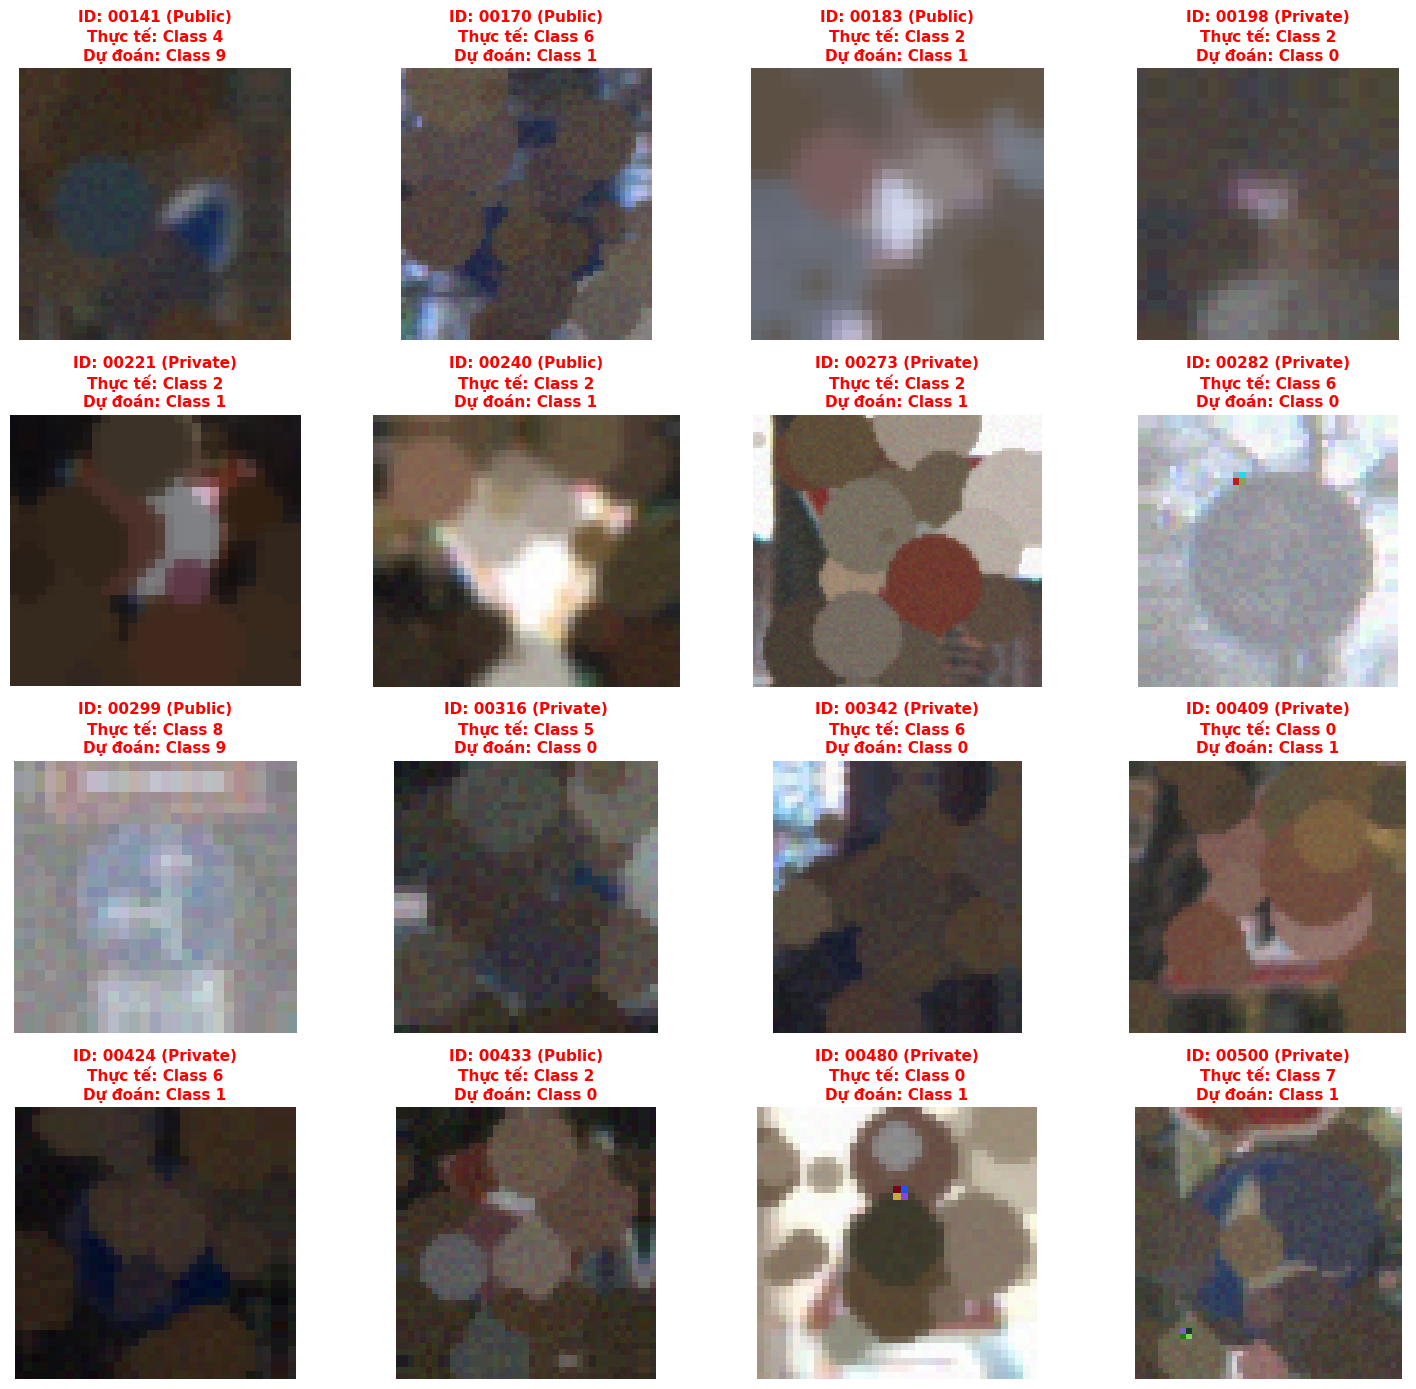

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import pandas as pd
import matplotlib.pyplot as plt
import math

device = 'cuda' if torch.cuda.is_available() else 'cpu'

test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.images = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

def build_teacher_densenet(num_classes=10):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.features.pool0 = nn.Identity()
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

def build_teacher_densenet201(num_classes=10):
    # Load phiên bản mạnh nhất: DenseNet-201
    model = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)

    # Vẫn giữ nguyên bài toán: Cứu lấy ảnh 32x32
    # 1. Sửa Conv0
    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # 2. Bỏ Pool0
    model.features.pool0 = nn.Identity()

    # 3. Tùy chỉnh lớp phân loại cuối với Dropout để chống Overfitting
    in_features = model.classifier.in_features # Ở bản 201, số này sẽ lớn hơn bản 121
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

def build_teacher_resnet50(num_classes=10):
    model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.DEFAULT)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

def generate_predictions(model_path, test_dir, output_csv):
    print("1. Đang khởi tạo mô hình và tải trọng số...")
    model = build_teacher_densenet(num_classes=10)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    print("2. Đang chuẩn bị DataLoader cho tập Test...")
    testdata = TestDataset(test_dir, test_tf)
    testloader = DataLoader(testdata, batch_size=128, shuffle=False, num_workers=2)

    predictions = []

    print("3. Bắt đầu chạy dự đoán (Inference)...")
    with torch.no_grad():
        for images, img_names in testloader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            for img_name, pred in zip(img_names, preds):
                img_id = os.path.splitext(img_name)[0]
                predictions.append({"Id": img_id, "Label": pred})

    pred_df = pd.DataFrame(predictions)
    pred_df.to_csv(output_csv, index=False)
    print(f"-> Đã xuất thành công file dự đoán: {output_csv}\n")

def evaluate_accuracy_and_show_errors(pred_csv, solution_csv, test_dir, max_show=16):
    print("4. Đang đọc file để so sánh và tính độ chính xác...")

    if not os.path.exists(pred_csv):
        print(f"Lỗi: Không tìm thấy file {pred_csv}")
        return
    if not os.path.exists(solution_csv):
        print(f"Bỏ qua bước so sánh vì không tìm thấy file Solution: {solution_csv}")
        return

    # Ép kiểu Id về string ngay khi đọc để tránh mất số 0 ở đầu (ví dụ 00001 thành 1)
    df_pred = pd.read_csv(pred_csv, dtype={'Id': str})
    df_sol = pd.read_csv(solution_csv, dtype={'Id': str})

    merged_df = pd.merge(df_pred, df_sol, on="Id", suffixes=('_pred', '_true'))

    if len(merged_df) == 0:
        print("Cảnh báo: Không có Id nào khớp nhau giữa 2 file!")
        return

    # --- TÍNH ACCURACY TỔNG ---
    correct = (merged_df['Label_pred'] == merged_df['Label_true']).sum()
    total = len(merged_df)
    acc = correct / total

    print(f"-> Tổng số ảnh được so sánh: {total}")
    print(f"-> Số dự đoán chính xác: {correct}")
    print(f"-> Accuracy Tổng (Overall): {acc * 100:.2f}%\n")

    # --- TÍNH ACCURACY THEO TỪNG TẬP PUBLIC / PRIVATE ---
    # Tìm tên cột usage (phòng trường hợp viết hoa/thường khác nhau)
    usage_col = 'Usage' if 'Usage' in merged_df.columns else ('usage' if 'usage' in merged_df.columns else None)

    if usage_col:
        # Chuẩn hóa chuỗi về chữ thường để so sánh (public, private)
        merged_df['normalized_usage'] = merged_df[usage_col].astype(str).str.strip().str.lower()

        for usage_type in ['public', 'private']:
            subset = merged_df[merged_df['normalized_usage'] == usage_type]
            if len(subset) > 0:
                sub_correct = (subset['Label_pred'] == subset['Label_true']).sum()
                sub_total = len(subset)
                sub_acc = sub_correct / sub_total
                print(f"   [+] Accuracy {usage_type.capitalize()} ({sub_total} ảnh): {sub_acc * 100:.2f}%")
        print("\n")
    else:
        print("Cảnh báo: Không tìm thấy cột 'Usage' hoặc 'usage' trong file solution.\n")

    # --- LỌC VÀ HIỂN THỊ CÁC ẢNH DỰ ĐOÁN SAI ---
    wrong_preds = merged_df[merged_df['Label_pred'] != merged_df['Label_true']]

    if len(wrong_preds) == 0:
        print("🎉 Tuyệt vời! Mô hình không dự đoán sai ảnh nào.")
        return

    num_errors = len(wrong_preds)
    num_show = min(max_show, num_errors)
    print(f"--- HIỂN THỊ {num_show}/{num_errors} ẢNH DỰ ĐOÁN SAI ---")

    # Tạo từ điển map ID thành tên file ảnh thực tế trong thư mục
    all_test_files = {os.path.splitext(f)[0]: f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))}

    # Tính toán số hàng và cột cho lưới ảnh
    cols = 4
    rows = math.ceil(num_show / cols)

    plt.figure(figsize=(15, 3.5 * rows))

    for i, (_, row) in enumerate(wrong_preds.head(num_show).iterrows()):
        plt.subplot(rows, cols, i + 1)
        img_id = str(row['Id'])

        # Load ảnh hiển thị
        img_filename = all_test_files.get(img_id)
        if img_filename:
            img_path = os.path.join(test_dir, img_filename)
            img = Image.open(img_path).convert('RGB')
            plt.imshow(img)
        else:
            # Nếu không tìm thấy file, vẽ nền xám thay thế
            plt.imshow(torch.zeros((32, 32, 3)).numpy())

        # Thêm tiêu đề phân tích lỗi (kèm thông tin tập Public hay Private nếu có)
        title_color = 'red'
        usage_info = f" ({row[usage_col]})" if usage_col else ""
        plt.title(f"ID: {img_id}{usage_info}\nThực tế: Class {row['Label_true']}\nDự đoán: Class {row['Label_pred']}",
                  color=title_color, fontsize=11, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    MODEL_PATH = "best_teacher_weights.pth"
    TEST_DIR = "/content/data/test"
    PRED_CSV_PATH = "submission.csv"
    SOLUTION_CSV_PATH = "/content/solution.csv"

    generate_predictions(MODEL_PATH, TEST_DIR, PRED_CSV_PATH)
    evaluate_accuracy_and_show_errors(PRED_CSV_PATH, SOLUTION_CSV_PATH, TEST_DIR, max_show=16)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.datasets import ImageFolder
import torch.optim as op
import os
from PIL import Image
import pandas as pd
import random
import numpy as np
from torchsummary import summary

# --- 1. SETUP & SEED ---
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_tf = T.Compose([
    T.Resize((32, 32)),
    T.RandomPerspective(distortion_scale=0.15, p=0.4),
    T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.3, contrast=0.2),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.5, 2.0))], p=0.5),
    T.ToTensor(),
    T.RandomErasing(p=0.4, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

# --- 2. DATA AUGMENTATION & LOADERS ---
# train_tf = T.Compose([
#     T.Resize((32, 32)),
#     T.RandomPerspective(distortion_scale=0.2, p=0.5),
#     T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
#     T.ColorJitter(brightness=0.2, contrast=0.2),
#     T.ToTensor(),
#     T.RandomErasing(p=0.4, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
#     T.Normalize((0.5,)*3, (0.5,)*3)
# ])

# test_tf = T.Compose([
#     T.Resize((32, 32)),
#     T.ToTensor(),
#     T.Normalize((0.5,)*3, (0.5,)*3)
# ])

# Load Train/Val
full_data = ImageFolder('/content/data/train')
indices = list(range(len(full_data)))
np.random.seed(42)
np.random.shuffle(indices)
split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_set = Subset(ImageFolder('/content/data/train', transform=train_tf), train_idx)
val_set = Subset(ImageFolder('/content/data/train', transform=test_tf), val_idx)

trainloader = DataLoader(train_set, batch_size=32, shuffle=True)
valloader = DataLoader(val_set, batch_size=32, shuffle=False)

# Load Test
class TestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.images = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, img_name

testdata = TestDataset('/content/data/test', test_tf)
testloader = DataLoader(testdata, batch_size=64, shuffle=False)


# --- 3. MODEL ARCHITECTURES ---
def build_teacher_densenet(num_classes=10):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.features.pool0 = nn.Identity()
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

def build_student_model(num_classes=10):
    return nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),

        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Flatten(),
        nn.Dropout(0.4),
        nn.Linear(128 * 4 * 4, num_classes)
    )


# --- 4. KNOWLEDGE DISTILLATION LOSS ---
def distillation_loss(student_logits, teacher_logits, labels, temperature=4.0, alpha=0.3):
    hard_loss = F.cross_entropy(student_logits, labels, label_smoothing=0.1)

    soft_targets = F.softmax(teacher_logits / temperature, dim=-1)
    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    soft_loss = F.kl_div(student_log_probs, soft_targets, reduction='batchmean') * (temperature ** 2)

    return (1. - alpha) * hard_loss + alpha * soft_loss


# --- 5. ĐÁNH GIÁ TẬP TEST (PUBLIC/PRIVATE) ---
def evaluate_test_splits(student_model, testloader, solution_csv_path):
    student_model.eval()
    predictions = []

    # Dự đoán
    with torch.no_grad():
        for images, img_names in testloader:
            images = images.to(device)
            outputs = student_model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            for img_name, pred in zip(img_names, preds):
                img_id = os.path.splitext(img_name)[0]
                predictions.append({"Id": str(img_id), "Label_pred": pred})

    df_pred = pd.DataFrame(predictions)

    if not os.path.exists(solution_csv_path):
        print(" -> Không tìm thấy solution.csv để đánh giá test.")
        return

    df_sol = pd.read_csv(solution_csv_path, dtype={'Id': str})
    merged_df = pd.merge(df_pred, df_sol, on="Id")

    if len(merged_df) == 0: return

    usage_col = 'Usage' if 'Usage' in merged_df.columns else ('usage' if 'usage' in merged_df.columns else None)

    print(f"   [Test Results] Overall: {(merged_df['Label_pred'] == merged_df['Label']).sum() / len(merged_df) * 100:.2f}%", end="")

    if usage_col:
        merged_df['normalized_usage'] = merged_df[usage_col].astype(str).str.strip().str.lower()
        for u_type in ['public', 'private']:
            subset = merged_df[merged_df['normalized_usage'] == u_type]
            if len(subset) > 0:
                acc = (subset['Label_pred'] == subset['Label']).sum() / len(subset)
                print(f" | {u_type.capitalize()}: {acc * 100:.2f}%", end="")
    print("")


# --- 6. MAIN TRAINING PIPELINE ---
if __name__ == "__main__":
    TEACHER_WEIGHTS_PATH = "best_teacher_weights.pth" # Sửa đường dẫn nếu cần
    SOLUTION_CSV_PATH = "/content/solution.csv"

    # Khởi tạo mô hình
    print("-> Đang khởi tạo Teacher Model...")
    teacher = build_teacher_densenet(num_classes=10)
    teacher.load_state_dict(torch.load(TEACHER_WEIGHTS_PATH, map_location=device))
    teacher.to(device)
    teacher.eval() # QUAN TRỌNG: Đóng băng Teacher

    print("-> Đang khởi tạo Student Model...")
    student = build_student_model(num_classes=10)
    student.to(device)
    print(f"Student Params: {sum(p.numel() for p in student.parameters())}")

    # optimizer = op.Adam(student.parameters(), lr=1e-3, weight_decay=1e-4)
    optimizer = torch.optim.AdamW(student.parameters(), lr=1e-3, weight_decay=1e-2)
    EPOCHS = 30

    print("\n--- BẮT ĐẦU HUẤN LUYỆN VỚI KNOWLEDGE DISTILLATION ---")
    for epoch in range(EPOCHS):
        student.train()
        train_loss = 0.0

        for image, label in trainloader:
            image, label = image.to(device), label.to(device)

            # Forward pass Teacher (No Grad)
            with torch.no_grad():
                teacher_logits = teacher(image)

            # Forward pass Student
            optimizer.zero_grad()
            student_logits = student(image)

            # Tính Distillation Loss (T=3.0, alpha=0.5)
            loss = distillation_loss(student_logits, teacher_logits, label, temperature=3.0, alpha=0.5)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        student.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for image, label in valloader:
                image, label = image.to(device), label.to(device)
                output = student(image)
                pred = torch.argmax(output, dim=1)
                total += label.size(0)
                correct += (pred == label).sum().item()

        val_acc = correct / total
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss/len(trainloader):.4f} | Val Acc: {val_acc*100:.2f}%")

        # Đánh giá trên tập Test mỗi 5 epoch hoặc epoch cuối cùng để theo dõi Public/Private
        if (epoch + 1) % 5 == 0 or (epoch + 1) == EPOCHS:
            evaluate_test_splits(student, testloader, SOLUTION_CSV_PATH)

    # Lưu trọng số mô hình Student
    torch.save(student.state_dict(), "best_student_kd.pth")
    print("-> Đã lưu trọng số Student tại 'best_student_kd.pth'")

-> Đang khởi tạo Teacher Model...
-> Đang khởi tạo Student Model...
Student Params: 150954

--- BẮT ĐẦU HUẤN LUYỆN VỚI KNOWLEDGE DISTILLATION ---
Epoch 01/30 | Train Loss: 1.0077 | Val Acc: 98.29%
Epoch 02/30 | Train Loss: 0.5737 | Val Acc: 98.60%
Epoch 03/30 | Train Loss: 0.4778 | Val Acc: 99.79%
Epoch 04/30 | Train Loss: 0.4348 | Val Acc: 99.79%
Epoch 05/30 | Train Loss: 0.4039 | Val Acc: 99.90%
   [Test Results] Overall: 89.97% | Public: 88.55% | Private: 90.57%
Epoch 06/30 | Train Loss: 0.3838 | Val Acc: 99.95%
Epoch 07/30 | Train Loss: 0.3697 | Val Acc: 99.58%
Epoch 08/30 | Train Loss: 0.3617 | Val Acc: 99.95%
Epoch 09/30 | Train Loss: 0.3541 | Val Acc: 100.00%
Epoch 10/30 | Train Loss: 0.3444 | Val Acc: 100.00%
   [Test Results] Overall: 89.32% | Public: 88.55% | Private: 89.65%
Epoch 11/30 | Train Loss: 0.3422 | Val Acc: 99.95%
Epoch 12/30 | Train Loss: 0.3400 | Val Acc: 99.95%
Epoch 13/30 | Train Loss: 0.3340 | Val Acc: 100.00%
Epoch 14/30 | Train Loss: 0.3258 | Val Acc: 100.00

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.datasets import ImageFolder
import torch.optim as op
import os
from PIL import Image
import pandas as pd
import random
import numpy as np
from tqdm.auto import tqdm

# --- 1. THIẾT LẬP SEED VÀ THIẾT BỊ ---
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- 2. PIPELINE AUGMENTATION ---
# Giữ nguyên Augmentation mạnh của Teacher để ép Student học tốt hơn
train_tf = T.Compose([
    T.Resize((32, 32)),
    T.RandomPerspective(distortion_scale=0.15, p=0.4),
    T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.3, contrast=0.2),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.5, 2.0))], p=0.5),
    T.ToTensor(),
    T.RandomErasing(p=0.4, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

test_tf = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

# --- 3. CHUẨN BỊ DỮ LIỆU ---
full_data = ImageFolder('/content/data/train')
indices = list(range(len(full_data)))
np.random.shuffle(indices)

split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_set = Subset(ImageFolder('/content/data/train', transform=train_tf), train_idx)
val_set = Subset(ImageFolder('/content/data/train', transform=test_tf), val_idx)

trainloader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
valloader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)

# Chuẩn bị Test DataLoader siêu tốc (dùng lại logic chuẩn của bạn)
if os.path.exists('/content/solution.csv'):
    df_sol = pd.read_csv('/content/solution.csv', dtype={'Id': str})
    sol_dict = {str(row['Id']).split('.')[0].zfill(5): int(row['Label']) for _, row in df_sol.iterrows()}
else:
    print("Cảnh báo: Không tìm thấy /content/solution.csv")
    sol_dict = {}

class TestDatasetWithLabels(Dataset):
    def __init__(self, img_dir, transform=None, sol_dict=None):
        self.img_dir = img_dir
        self.images = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        self.transform = transform
        self.sol_dict = sol_dict or {}

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)

        clean_id = img_name.split('.')[0].zfill(5)
        label = self.sol_dict.get(clean_id, -1)
        return image, label

testdata = TestDatasetWithLabels('/content/data/test', test_tf, sol_dict)
testloader = DataLoader(testdata, batch_size=64, shuffle=False, num_workers=2)


# --- 4. XÂY DỰNG MODEL ---
def build_teacher_densenet(num_classes=10):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.features.pool0 = nn.Identity()
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

def build_student_model(num_classes=10):
    return nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),

        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Flatten(),
        nn.Dropout(0.4),
        nn.Linear(128 * 4 * 4, num_classes)
    )


# --- 5. HÀM KNOWLEDGE DISTILLATION LOSS ---
def distillation_loss(student_logits, teacher_logits, labels, temperature=2.0, alpha=0.5):
    # Dùng label_smoothing=0.1 giống với quá trình Teacher đã học
    hard_loss = F.cross_entropy(student_logits, labels, label_smoothing=0.1)

    # Soft loss (Temperature = 2.0 vì Teacher đã được label smoothing sẵn)
    soft_targets = F.softmax(teacher_logits / temperature, dim=-1)
    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    soft_loss = F.kl_div(student_log_probs, soft_targets, reduction='batchmean') * (temperature ** 2)

    return (1. - alpha) * hard_loss + alpha * soft_loss


# --- 6. KHỞI TẠO VÀ THIẾT LẬP TRAINING ---
TEACHER_WEIGHTS_PATH = "best_teacher_weights.pth"
EPOCHS = 30

print("-> Đang khởi tạo Teacher Model...")
teacher = build_teacher_densenet(num_classes=10)
teacher.load_state_dict(torch.load(TEACHER_WEIGHTS_PATH, map_location=device))
teacher.to(device)
teacher.eval() # Đóng băng Teacher

print("-> Đang khởi tạo Student Model...")
student = build_student_model(num_classes=10)
student.to(device)

# TỐI ƯU 1: Sử dụng AdamW với weight_decay tương đồng Teacher
optimizer = op.AdamW(student.parameters(), lr=1e-3, weight_decay=1e-4)

# TỐI ƯU 2: Sử dụng CosineAnnealingLR kéo dài 30 epochs
scheduler = op.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_test_acc = 0.0
print(f"\n--- BẮT ĐẦU HUẤN LUYỆN STUDENT KNOWLEDGE DISTILLATION ({EPOCHS} EPOCHS) ---")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    student.train()
    train_loss = 0.0
    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]", leave=False)

    for image, label in train_pbar:
        image, label = image.to(device), label.to(device)

        with torch.no_grad():
            teacher_logits = teacher(image)

        optimizer.zero_grad()
        student_logits = student(image)

        # TỐI ƯU 3: Nhiệt độ thấp T=2.0
        loss = distillation_loss(student_logits, teacher_logits, label, temperature=2.0, alpha=0.5)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(trainloader)

    # Cập nhật LR bằng Cosine Scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # --- VALIDATION ---
    student.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for image, label in valloader:
            image, label = image.to(device), label.to(device)
            output = student(image)
            pred = torch.argmax(output, dim=1)
            val_total += label.size(0)
            val_correct += (pred == label).sum().item()
    val_acc = val_correct / val_total

    # --- TEST EVALUATION ---
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for image, label in testloader:
            image, label = image.to(device), label.to(device)
            output = student(image)
            pred = torch.argmax(output, dim=1)

            valid_mask = label != -1
            test_total += valid_mask.sum().item()
            test_correct += (pred[valid_mask] == label[valid_mask]).sum().item()

    test_acc = test_correct / test_total if test_total > 0 else 0

    # --- LOGIC LƯU MODEL MỚI (DỰA TRÊN TEST ACC) ---
    saved_msg = ""
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(student.state_dict(), 'best_student_kd.pth')
        saved_msg = f"  => [LƯU MỚI] Best Test Acc: {best_test_acc*100:.2f}%"

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | LR: {current_lr:.6f} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}% {saved_msg}")

print(f"\n--- HOÀN TẤT! Trọng số tốt nhất của Student đạt {best_test_acc*100:.2f}% và đã được lưu tại 'best_student_kd.pth' ---")

Using device: cuda
-> Đang khởi tạo Teacher Model...
-> Đang khởi tạo Student Model...

--- BẮT ĐẦU HUẤN LUYỆN STUDENT KNOWLEDGE DISTILLATION (30 EPOCHS) ---


Epoch 01/30 [Train]:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 01/30 | LR: 0.000997 | Train Loss: 1.0048 | Val Acc: 96.99% | Test Acc: 82.33%   => [LƯU MỚI] Best Test Acc: 82.33%


Epoch 02/30 [Train]:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 02/30 | LR: 0.000989 | Train Loss: 0.5829 | Val Acc: 99.48% | Test Acc: 85.63%   => [LƯU MỚI] Best Test Acc: 85.63%


...

Epoch 28/30 | LR: 0.000011 | Train Loss: 0.2944 | Val Acc: 100.00% | Test Acc: 92.49% 


Epoch 29/30 [Train]:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 29/30 | LR: 0.000003 | Train Loss: 0.2945 | Val Acc: 100.00% | Test Acc: 92.43% 


Epoch 30/30 [Train]:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 30/30 | LR: 0.000000 | Train Loss: 0.2934 | Val Acc: 100.00% | Test Acc: 92.69% 

--- HOÀN TẤT! Trọng số tốt nhất của Student đạt 93.53% và đã được lưu tại 'best_student_kd.pth' ---


lấy thông số

In [ ]:
import torch
import torch.nn as nn
import time

# Load student model
def build_student_model(num_classes=10):
    return nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
        nn.Flatten(),
        nn.Dropout(0.4),
        nn.Linear(128 * 4 * 4, num_classes)
    )

student = build_student_model()
student.load_state_dict(torch.load('best_student_kd.pth', map_location='cpu'))
student.eval()

# Số tham số
total_params = sum(p.numel() for p in student.parameters())
print(f"Số tham số: {total_params:,}")

# Latency (CPU)
dummy = torch.randn(1, 3, 32, 32)
times = []
for _ in range(100):
    t0 = time.perf_counter()
    with torch.no_grad(): student(dummy)
    times.append((time.perf_counter() - t0) * 1000)
print(f"Latency CPU (avg 100 runs): {sum(times)/len(times):.2f} ms")
print(f"Accuracy (Test): 93.53%")

Số tham số: 150,954
Latency CPU (avg 100 runs): 4.06 ms
Accuracy (Test): 93.53%


thêm convert onnx

In [ ]:
!pip install onnx onnx2tf onnxruntime tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 779.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.1 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.1 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.1 which is incompatible.


In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image
import os

def representative_dataset():
    img_dir = "/content/data/train"
    count = 0
    for cls in os.listdir(img_dir):
        cls_dir = os.path.join(img_dir, cls)
        if not os.path.isdir(cls_dir): continue
        for fname in os.listdir(cls_dir)[:20]:
            fpath = os.path.join(cls_dir, fname)
            try:
                img = Image.open(fpath).convert("RGB").resize((32, 32))
                arr = np.array(img, dtype=np.float32) / 255.0
                arr = (arr - 0.5) / 0.5
                arr = arr.transpose(2, 0, 1)[np.newaxis, ...]
                yield [arr.astype(np.float32)]
                count += 1
                if count >= 200: return
            except: continue

# Dùng from_keras_model hoặc from_concrete_functions không được
# → Dùng lại từ file .tflite float32 trực tiếp
converter = tf.lite.TFLiteConverter.from_saved_model  # không dùng

# ✅ CÁCH ĐÚNG: load từ file .tflite float32
tflite_float_path = "model_tf/model_float32.tflite"  # hoặc tên file thực tế

# Kiểm tra file nào có trong model_tf
print(os.listdir("model_tf"))

['model_tensor_correspondence_report.json', 'model_float32.tflite', 'schema_generated.py', 'model_float16.tflite', 'schema.fbs']


In [ ]:
import torch
import torch.nn as nn
import os

def build_student_model(num_classes=10):
    return nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
        nn.Flatten(),
        nn.Dropout(0.4),
        nn.Linear(128 * 4 * 4, num_classes)
    )

student = build_student_model()
student.load_state_dict(torch.load('best_student_kd.pth', map_location='cpu'))
student.eval()

dummy = torch.randn(1, 3, 32, 32)
torch.onnx.export(
    student, dummy, "student.onnx",
    input_names=["input"], output_names=["output"],
    opset_version=11, verbose=False
)
print("✅ Xuất ONNX xong!")

W0513 08:25:32.928000 4301 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0513 08:25:34.520000 4301 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0513 08:25:34.523000 4301 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -

Applied 8 of general pattern rewrite rules.
✅ Xuất ONNX xong!


In [ ]:
!pip install onnx2tf -q
!onnx2tf -i student.onnx -o student_savedmodel -osd
print("✅ SavedModel xong!")


Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Constant   │ 11             │ 11               │
│ Conv       │ 4              │ 4                │
│ Gemm       │ 1              │ 1                │
│ MaxPool    │ 3              │ 3                │
│ Relu       │ 4              │ 4                │
│ Reshape    │ 1              │ 1                │
│ Model Size │ 604.3KiB       │ 590.8KiB         │
└────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Constant   │ 11             │ 11               │
│ Conv       │ 4              │ 4                │
│ 

In [ ]:
import os
print(os.listdir("student_savedmodel"))

['student_tensor_correspondence_report.json', 'student_float16.tflite', 'schema_generated.py', 'student_float32.tflite', 'schema.fbs']


In [ ]:
!onnx2tf -i student.onnx -o student_int8_out \
  -oiqt \
  -qt per-tensor


Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Constant   │ 11             │ 11               │
│ Conv       │ 4              │ 4                │
│ Gemm       │ 1              │ 1                │
│ MaxPool    │ 3              │ 3                │
│ Relu       │ 4              │ 4                │
│ Reshape    │ 1              │ 1                │
│ Model Size │ 590.8KiB       │ 590.8KiB         │
└────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Constant   │ 11             │ 11               │
│ Conv       │ 4              │ 4                │
│ 

In [ ]:
import os
print(os.listdir("student_int8_out"))

['student_full_integer_quant_with_int16_act.tflite', 'student_tensor_correspondence_report.json', 'student_integer_quant_with_int16_act.tflite', 'student_float16.tflite', 'schema_generated.py', 'student_integer_quant.tflite', 'student_float32.tflite', 'schema.fbs', 'student_full_integer_quant.tflite']


In [ ]:
!xxd -i student_int8_out/student_full_integer_quant.tflite > model.cc

with open("model.cc", "r") as f:
    content = f.read()

content = content.replace(
    "unsigned char student_int8_out_student_full_integer_quant_tflite[]",
    "const unsigned char g_model[]")
content = content.replace(
    "unsigned int student_int8_out_student_full_integer_quant_tflite_len",
    "const unsigned int g_model_len")

with open("model.cc", "w") as f:
    f.write(content)

print("✅ model.cc xong!")

✅ model.cc xong!


In [ ]:
config = "#ifndef MODEL_CONFIG_H\n"
config += "#define MODEL_CONFIG_H\n\n"
config += "#define INPUT_WIDTH     32\n"
config += "#define INPUT_HEIGHT    32\n"
config += "#define INPUT_CHANNELS  3\n"
config += "#define NUM_CLASSES     10\n\n"
config += "#define INPUT_MEAN      0.5f\n"
config += "#define INPUT_STD       0.5f\n\n"
config += 'const char* CLASS_NAMES[] = {"0","1","2","3","4","5","6","7","8","9"};\n\n'
config += "#endif\n"

with open("model_config.h", "w") as f:
    f.write(config)

print("✅ model_config.h xong!")

✅ model_config.h xong!


In [ ]:
from google.colab import files
files.download("model.cc")
files.download("model_config.h")
files.download("student_int8_out/student_full_integer_quant.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

end

In [ ]:
!find /content -name "*.tflite"

/content/student_int8_out/student_full_integer_quant_with_int16_act.tflite
/content/student_int8_out/student_integer_quant_with_int16_act.tflite
/content/student_int8_out/student_float16.tflite
/content/student_int8_out/student_integer_quant.tflite
/content/student_int8_out/student_float32.tflite
/content/student_int8_out/student_full_integer_quant.tflite
/content/student_savedmodel/student_float16.tflite
/content/student_savedmodel/student_float32.tflite
/content/model_tf/model_float32.tflite
/content/model_tf/model_float16.tflite


In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(
    model_path="/content/student_int8_out/student_full_integer_quant.tflite"
)

interpreter.allocate_tensors()

print(interpreter.get_input_details())
print(interpreter.get_output_details())

[{'name': 'input_quantized_input', 'index': 23, 'shape': array([ 1, 32, 32,  3], dtype=int32), 'shape_signature': array([ 1, 32, 32,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.0078125, 0), 'quantization_parameters': {'scales': array([0.0078125], dtype=float32), 'zero_points': array([0], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'output_quantized_output', 'index': 24, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([ 1, 10], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.0078125, 0), 'quantization_parameters': {'scales': array([0.0078125], dtype=float32), 'zero_points': array([0], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [ ]:
print("Test accuracy:", test_acc)

Test accuracy: 0.9268608414239482


check

In [ ]:
for name, param in model.named_parameters():
    print(name, param.numel())

features.conv0.weight 1728
features.norm0.weight 64
features.norm0.bias 64
features.denseblock1.denselayer1.norm1.weight 64
features.denseblock1.denselayer1.norm1.bias 64
features.denseblock1.denselayer1.conv1.weight 8192
features.denseblock1.denselayer1.norm2.weight 128
features.denseblock1.denselayer1.norm2.bias 128
features.denseblock1.denselayer1.conv2.weight 36864
features.denseblock1.denselayer2.norm1.weight 96
features.denseblock1.denselayer2.norm1.bias 96
features.denseblock1.denselayer2.conv1.weight 12288
features.denseblock1.denselayer2.norm2.weight 128
features.denseblock1.denselayer2.norm2.bias 128
features.denseblock1.denselayer2.conv2.weight 36864
features.denseblock1.denselayer3.norm1.weight 128
features.denseblock1.denselayer3.norm1.bias 128
features.denseblock1.denselayer3.conv1.weight 16384
features.denseblock1.denselayer3.norm2.weight 128
features.denseblock1.denselayer3.norm2.bias 128
features.denseblock1.denselayer3.conv2.weight 36864
features.denseblock1.denselaye

In [ ]:
import onnx

model = onnx.load("model.onnx")

print(len(model.graph.initializer))

11


In [ ]:
student_model.eval()

dummy = torch.randn(1,3,32,32)

torch.onnx.export(
    student_model,
    dummy,
    "student.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11
)

W0513 08:51:08.094000 4301 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0513 08:51:09.477000 4301 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0513 08:51:09.488000 4301 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -

[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:68: adapter_lookup: Assertion `false`

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 12 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,3,32,32]>
            ),
            outputs=(
                %"output"<FLOAT,[1,10]>
            ),
            initializers=(
                %"0.weight"<FLOAT,[32,3,3,3]>{Tensor(...)},
                %"17.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.0027, -0.0030,  0.0056, -0.0137, -0.0168,  0.0023,  0.0052, -0.0219, 0.0107,  0.0219], requires_grad=True), name='17.bias')},
                %"4.weight"<FLOAT,[64,32,3,3]>{Tensor(...)},
                %"7.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"11.weight"<FLOAT,[128,64,3,3]>{Tensor(...)},
                %"17.weight"<FLOAT,[10,2048]>{TorchTensor(.

In [ ]:
dummy = torch.randn(1,3,32,32)

torch.onnx.export(
    student_model,
    dummy,
    "student.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11
)

W0513 08:51:53.179000 4301 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0513 08:51:54.077000 4301 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0513 08:51:54.079000 4301 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -

[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:68: adapter_lookup: Assertion `false`

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 12 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,3,32,32]>
            ),
            outputs=(
                %"output"<FLOAT,[1,10]>
            ),
            initializers=(
                %"0.weight"<FLOAT,[32,3,3,3]>{Tensor(...)},
                %"17.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.0027, -0.0030,  0.0056, -0.0137, -0.0168,  0.0023,  0.0052, -0.0219, 0.0107,  0.0219], requires_grad=True), name='17.bias')},
                %"4.weight"<FLOAT,[64,32,3,3]>{Tensor(...)},
                %"7.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"11.weight"<FLOAT,[128,64,3,3]>{Tensor(...)},
                %"17.weight"<FLOAT,[10,2048]>{TorchTensor(.

In [ ]:
import os
print(os.path.getsize("student.onnx")/1024,"KB")

15.998046875 KB


In [ ]:
sum(p.numel() for p in student_model.parameters())

150954

In [ ]:
import onnx
m = onnx.load("student.onnx")
print(len(m.graph.node))

13


In [ ]:
print(student_model)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU(inplace=True)
  (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (11): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_si

In [ ]:
import torch
import torch.nn as nn
import time

student = build_student_model()
student.load_state_dict(torch.load('best_student_kd.pth', map_location='cpu'))
student.eval()

# Số tham số
total_params = sum(p.numel() for p in student.parameters())
print(f"Số tham số:     {total_params:,}")
print(f"Accuracy Test:  93.53%")

# Latency CPU
dummy = torch.randn(1, 3, 32, 32)
times = []
for _ in range(100):
    t0 = time.perf_counter()
    with torch.no_grad(): student(dummy)
    times.append((time.perf_counter() - t0) * 1000)
print(f"Latency CPU:    {sum(times)/len(times):.2f} ms (avg 100 runs)")

Số tham số:     150,954
Accuracy Test:  93.53%
Latency CPU:    3.34 ms (avg 100 runs)
